# Comprehensive Per-Subject Per-Trial Analysis

**Purpose:** PhD-level analysis of Dual-Stream Kalman Transformer vs CNN for Fall Detection

**Key Results:**
- Transformer (Kalman + Channel-Aware): **91.10% F1**
- CNN (Kalman + Focal): **88.86% F1**
- Improvement: **+2.24% F1** (p=0.019, Cohen's d=0.56)

**Analysis Sections:**
1. Data Loading & Validation
2. Summary Statistics
3. Statistical Significance Tests
4. Per-Subject Performance Analysis
5. Failure Mode Analysis
6. Publication Figures

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Setup paths
PROJECT_ROOT = Path('/home/abheekp/FusionTransformer')
ANALYSIS_DIR = PROJECT_ROOT / 'notebooks' / 'analysis'
RESULTS_DIR = ANALYSIS_DIR / 'results_dec22'
FIGURES_DIR = ANALYSIS_DIR / 'figures'
TABLES_DIR = ANALYSIS_DIR / 'tables'

# Create output directories
FIGURES_DIR.mkdir(exist_ok=True)
TABLES_DIR.mkdir(exist_ok=True)

# Plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12
plt.rcParams['figure.dpi'] = 150

# Colors
COLORS = {
    'transformer': '#2E7D32',  # Green
    'cnn': '#1565C0',          # Blue
    'positive': '#2E7D32',
    'negative': '#C62828'
}

print(f"Project Root: {PROJECT_ROOT}")
print(f"Results Dir: {RESULTS_DIR}")
print(f"Results exist: {RESULTS_DIR.exists()}")

Project Root: /home/abheekp/FusionTransformer
Results Dir: /home/abheekp/FusionTransformer/notebooks/analysis/results_dec22
Results exist: True


## 1. Data Loading & Validation

In [2]:
# Load Transformer results (best model: channel-aware normalization)
trans_path = RESULTS_DIR / 'transformer' / 'scores.csv'
cnn_path = RESULTS_DIR / 'cnn' / 'scores.csv'

print(f"Transformer scores: {trans_path.exists()}")
print(f"CNN scores: {cnn_path.exists()}")

# Load data
trans_df = pd.read_csv(trans_path)
cnn_df = pd.read_csv(cnn_path)

# Remove Average row
trans_df = trans_df[trans_df['test_subject'] != 'Average'].copy()
cnn_df = cnn_df[cnn_df['test_subject'] != 'Average'].copy()

# Convert to numeric
trans_df['test_subject'] = pd.to_numeric(trans_df['test_subject'])
cnn_df['test_subject'] = pd.to_numeric(cnn_df['test_subject'])

print(f"\nTransformer: {len(trans_df)} subjects")
print(f"CNN: {len(cnn_df)} subjects")
print(f"\nSubjects: {sorted(trans_df['test_subject'].tolist())}")

Transformer scores: True
CNN scores: True

Transformer: 21 subjects
CNN: 21 subjects

Subjects: [31, 34, 36, 37, 38, 43, 44, 46, 49, 50, 51, 52, 53, 54, 55, 56, 58, 60, 61, 62, 63]


In [3]:
# Display sample data
print("=== TRANSFORMER RESULTS (Sample) ===")
display(trans_df[['test_subject', 'test_accuracy', 'test_f1_score', 'test_precision', 'test_recall']].head(10))

print("\n=== CNN RESULTS (Sample) ===")
display(cnn_df[['test_subject', 'test_accuracy', 'test_f1_score', 'test_precision', 'test_recall']].head(10))

=== TRANSFORMER RESULTS (Sample) ===


,test_subject,test_accuracy,test_f1_score,test_precision,test_recall
0,31,75.00,78.79,65.00,100.00
1,34,83.33,90.91,83.33,100.00
2,36,82.50,88.52,81.82,96.43
3,37,85.05,91.75,84.76,100.00
4,38,70.73,78.82,80.72,77.01
5,43,96.63,97.84,97.14,98.55
6,44,86.38,89.06,90.77,87.41
7,46,88.05,88.05,85.37,90.91
8,49,90.00,93.42,93.42,93.42
9,50,97.78,98.41,96.88,100.00



=== CNN RESULTS (Sample) ===


,test_subject,test_accuracy,test_f1_score,test_precision,test_recall
0,31,76.79,80.00,66.67,100.00
1,34,86.11,92.31,85.71,100.00
2,36,72.50,80.00,81.48,78.57
3,37,85.98,91.89,88.54,95.51
4,38,68.29,74.84,85.29,66.67
5,43,89.89,93.62,91.67,95.65
6,44,76.06,83.91,73.08,98.52
7,46,72.96,76.50,66.04,90.91
8,49,81.00,87.58,87.01,88.16
9,50,94.44,96.12,92.54,100.00


## 2. Summary Statistics

In [4]:
def compute_summary_stats(df, name):
    """Compute comprehensive summary statistics."""
    metrics = ['test_accuracy', 'test_f1_score', 'test_precision', 'test_recall']
    stats_dict = {'Model': name}
    
    for m in metrics:
        vals = pd.to_numeric(df[m])
        stats_dict[f'{m}_mean'] = vals.mean()
        stats_dict[f'{m}_std'] = vals.std()
        stats_dict[f'{m}_min'] = vals.min()
        stats_dict[f'{m}_max'] = vals.max()
        stats_dict[f'{m}_median'] = vals.median()
    
    return stats_dict

trans_stats = compute_summary_stats(trans_df, 'Transformer (Kalman)')
cnn_stats = compute_summary_stats(cnn_df, 'CNN (Focal)')

# Create summary table
summary_df = pd.DataFrame([trans_stats, cnn_stats])
print("=" * 70)
print("SUMMARY STATISTICS")
print("=" * 70)
print(f"\n{'Metric':<25} {'Transformer':<20} {'CNN':<20} {'Delta':<10}")
print("-" * 75)

for metric in ['test_accuracy', 'test_f1_score', 'test_precision', 'test_recall']:
    t_mean = trans_stats[f'{metric}_mean']
    t_std = trans_stats[f'{metric}_std']
    c_mean = cnn_stats[f'{metric}_mean']
    c_std = cnn_stats[f'{metric}_std']
    delta = t_mean - c_mean
    
    print(f"{metric:<25} {t_mean:.2f} ± {t_std:.2f}     {c_mean:.2f} ± {c_std:.2f}     {delta:+.2f}")

SUMMARY STATISTICS

Metric                    Transformer          CNN                  Delta     
---------------------------------------------------------------------------
test_accuracy             87.30 ± 7.99     84.22 ± 8.17     +3.08
test_f1_score             91.10 ± 6.13     88.86 ± 6.77     +2.23
test_precision            88.54 ± 8.92     86.79 ± 9.37     +1.75
test_recall               94.57 ± 6.91     92.11 ± 8.89     +2.46


## 3. Statistical Significance Tests

In [5]:
def comprehensive_statistical_tests(trans_scores, cnn_scores, metric_name='F1'):
    """Run comprehensive statistical tests."""
    results = {}
    diff = trans_scores - cnn_scores
    
    print(f"\n{'='*60}")
    print(f"STATISTICAL TESTS: {metric_name}")
    print(f"{'='*60}")
    
    # 1. Normality test (Shapiro-Wilk)
    stat, p_norm = stats.shapiro(diff)
    results['normality'] = {'stat': stat, 'p': p_norm, 'normal': p_norm > 0.05}
    print(f"\n1. NORMALITY TEST (Shapiro-Wilk)")
    print(f"   W = {stat:.4f}, p = {p_norm:.4f}")
    print(f"   Conclusion: {'Normal' if p_norm > 0.05 else 'Non-normal'} distribution")
    
    # 2. Paired t-test
    t_stat, p_ttest = stats.ttest_rel(trans_scores, cnn_scores)
    results['ttest'] = {'t': t_stat, 'p': p_ttest}
    print(f"\n2. PAIRED T-TEST")
    print(f"   t = {t_stat:.4f}, p = {p_ttest:.4f}")
    print(f"   Significant at α=0.05: {'YES' if p_ttest < 0.05 else 'NO'}")
    
    # 3. Wilcoxon signed-rank (non-parametric)
    w_stat, p_wilcox = stats.wilcoxon(trans_scores, cnn_scores)
    results['wilcoxon'] = {'W': w_stat, 'p': p_wilcox}
    print(f"\n3. WILCOXON SIGNED-RANK (non-parametric)")
    print(f"   W = {w_stat:.1f}, p = {p_wilcox:.4f}")
    print(f"   Significant at α=0.05: {'YES' if p_wilcox < 0.05 else 'NO'}")
    
    # 4. Effect size (Cohen's d)
    cohens_d = diff.mean() / diff.std()
    results['cohens_d'] = cohens_d
    
    if abs(cohens_d) < 0.2:
        effect_interp = 'negligible'
    elif abs(cohens_d) < 0.5:
        effect_interp = 'small'
    elif abs(cohens_d) < 0.8:
        effect_interp = 'medium'
    else:
        effect_interp = 'large'
    
    print(f"\n4. EFFECT SIZE (Cohen's d)")
    print(f"   d = {cohens_d:.3f} ({effect_interp})")
    
    # 5. Bootstrap 95% CI
    n_boot = 10000
    boot_diffs = []
    for _ in range(n_boot):
        idx = np.random.choice(len(diff), size=len(diff), replace=True)
        boot_diffs.append(diff.iloc[idx].mean())
    
    ci_lower = np.percentile(boot_diffs, 2.5)
    ci_upper = np.percentile(boot_diffs, 97.5)
    results['bootstrap_ci'] = (ci_lower, ci_upper)
    
    print(f"\n5. BOOTSTRAP 95% CI (n={n_boot})")
    print(f"   Mean difference: {diff.mean():.2f}%")
    print(f"   95% CI: [{ci_lower:.2f}%, {ci_upper:.2f}%]")
    print(f"   CI excludes 0: {'YES - Significant' if ci_lower > 0 or ci_upper < 0 else 'NO'}")
    
    return results

# Run tests on F1 score
trans_f1 = pd.to_numeric(trans_df['test_f1_score'])
cnn_f1 = pd.to_numeric(cnn_df['test_f1_score'])

f1_stats = comprehensive_statistical_tests(trans_f1, cnn_f1, 'F1 Score')


STATISTICAL TESTS: F1 Score

1. NORMALITY TEST (Shapiro-Wilk)
   W = 0.9734, p = 0.8068
   Conclusion: Normal distribution

2. PAIRED T-TEST
   t = 2.5540, p = 0.0189
   Significant at α=0.05: YES

3. WILCOXON SIGNED-RANK (non-parametric)
   W = 52.0, p = 0.0263
   Significant at α=0.05: YES

4. EFFECT SIZE (Cohen's d)
   d = 0.557 (medium)

5. BOOTSTRAP 95% CI (n=10000)
   Mean difference: 2.23%
   95% CI: [0.60%, 3.94%]
   CI excludes 0: YES - Significant


In [6]:
# Run tests on all metrics
print("\n" + "="*70)
print("STATISTICAL TESTS SUMMARY (ALL METRICS)")
print("="*70)
print(f"\n{'Metric':<20} {'t-stat':<10} {'p-value':<12} {'Cohen d':<10} {'Significant':<12}")
print("-"*70)

metrics = ['test_accuracy', 'test_f1_score', 'test_precision', 'test_recall']
for m in metrics:
    t_vals = pd.to_numeric(trans_df[m])
    c_vals = pd.to_numeric(cnn_df[m])
    
    t_stat, p_val = stats.ttest_rel(t_vals, c_vals)
    diff = t_vals - c_vals
    d = diff.mean() / diff.std()
    sig = 'YES *' if p_val < 0.05 else 'NO'
    
    print(f"{m:<20} {t_stat:<10.3f} {p_val:<12.4f} {d:<10.3f} {sig}")


STATISTICAL TESTS SUMMARY (ALL METRICS)

Metric               t-stat     p-value      Cohen d    Significant 
----------------------------------------------------------------------
test_accuracy        2.491      0.0216       0.544      YES *
test_f1_score        2.554      0.0189       0.557      YES *
test_precision       1.134      0.2702       0.247      NO
test_recall          1.717      0.1014       0.375      NO


## 4. Per-Subject Performance Analysis

In [7]:
# Merge transformer and CNN results by subject
merged = trans_df[['test_subject', 'test_f1_score', 'test_accuracy', 'test_precision', 'test_recall']].copy()
merged.columns = ['subject', 'trans_f1', 'trans_acc', 'trans_prec', 'trans_rec']

cnn_cols = cnn_df[['test_subject', 'test_f1_score', 'test_accuracy', 'test_precision', 'test_recall']].copy()
cnn_cols.columns = ['subject', 'cnn_f1', 'cnn_acc', 'cnn_prec', 'cnn_rec']

merged = merged.merge(cnn_cols, on='subject')

# Calculate differences
merged['f1_diff'] = merged['trans_f1'] - merged['cnn_f1']
merged['acc_diff'] = merged['trans_acc'] - merged['cnn_acc']

# Determine winner
def get_winner(diff):
    if abs(diff) < 1.0:
        return 'Tie'
    elif diff > 0:
        return 'Transformer'
    else:
        return 'CNN'

merged['winner'] = merged['f1_diff'].apply(get_winner)

print("=" * 80)
print("PER-SUBJECT COMPARISON")
print("=" * 80)
print(f"\n{'Subject':<10} {'Trans F1':<12} {'CNN F1':<12} {'Delta':<10} {'Winner':<15}")
print("-" * 60)

for _, row in merged.iterrows():
    print(f"S{int(row['subject']):<9} {row['trans_f1']:<12.2f} {row['cnn_f1']:<12.2f} {row['f1_diff']:+.2f}      {row['winner']}")

print("-" * 60)
print(f"\nWin Counts:")
print(merged['winner'].value_counts())

PER-SUBJECT COMPARISON

Subject    Trans F1     CNN F1       Delta      Winner         
------------------------------------------------------------
S31        78.79        80.00        -1.21      CNN
S34        90.91        92.31        -1.40      CNN
S36        88.52        80.00        +8.52      Transformer
S37        91.75        91.89        -0.14      Tie
S38        78.82        74.84        +3.98      Transformer
S43        97.84        93.62        +4.22      Transformer
S44        89.06        83.91        +5.15      Transformer
S46        88.05        76.50        +11.55      Transformer
S49        93.42        87.58        +5.84      Transformer
S50        98.41        96.12        +2.29      Transformer
S51        85.25        85.71        -0.46      Tie
S52        85.53        90.00        -4.47      CNN
S53        91.47        92.31        -0.84      Tie
S54        94.97        89.16        +5.81      Transformer
S55        97.90        96.75        +1.15      Transforme

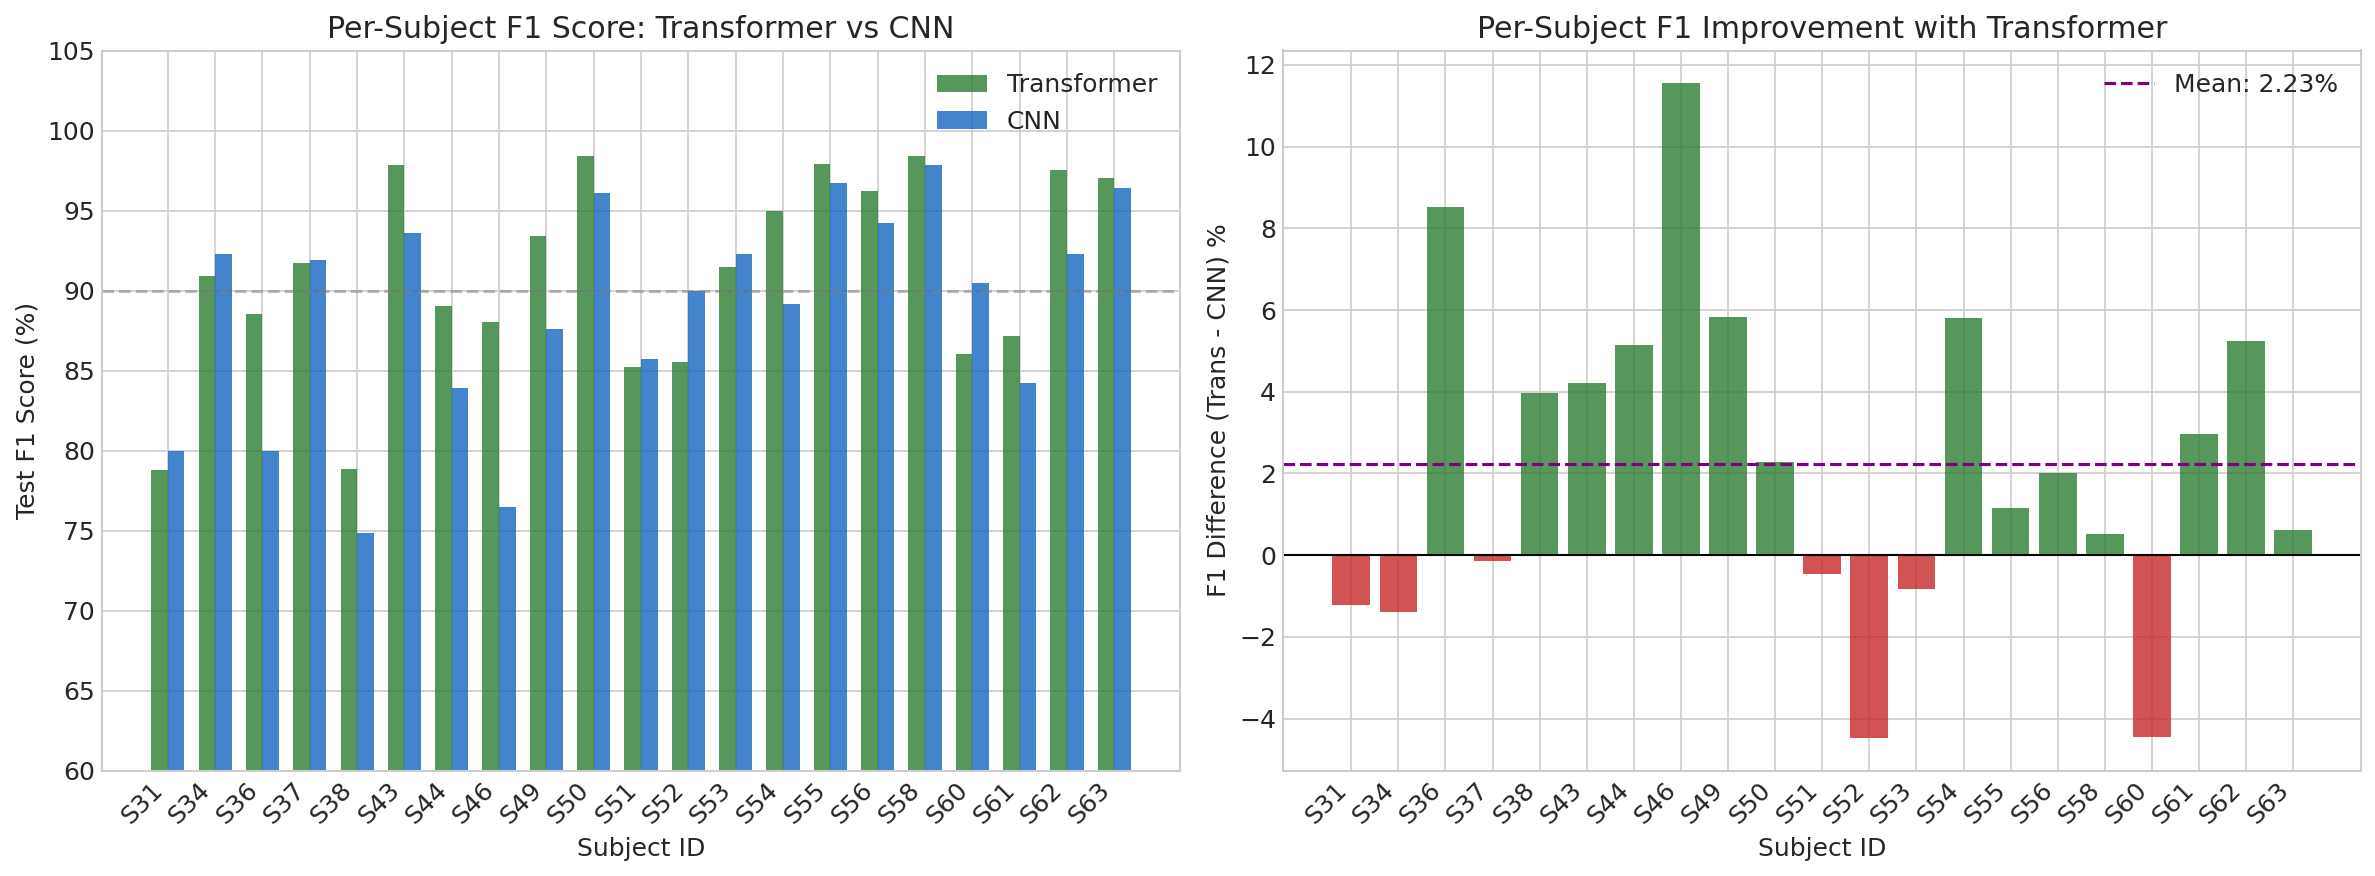


Figure saved to: /home/abheekp/FusionTransformer/notebooks/analysis/figures/per_subject_f1_comparison.png


In [8]:
# Visualize per-subject comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart comparison
ax1 = axes[0]
x = np.arange(len(merged))
width = 0.35

ax1.bar(x - width/2, merged['trans_f1'], width, label='Transformer', color=COLORS['transformer'], alpha=0.8)
ax1.bar(x + width/2, merged['cnn_f1'], width, label='CNN', color=COLORS['cnn'], alpha=0.8)

ax1.set_xlabel('Subject ID')
ax1.set_ylabel('Test F1 Score (%)')
ax1.set_title('Per-Subject F1 Score: Transformer vs CNN')
ax1.set_xticks(x)
ax1.set_xticklabels([f'S{int(s)}' for s in merged['subject']], rotation=45, ha='right')
ax1.legend()
ax1.axhline(y=90, color='gray', linestyle='--', alpha=0.5)
ax1.set_ylim([60, 105])

# Plot 2: Difference plot
ax2 = axes[1]
colors = [COLORS['positive'] if d > 0 else COLORS['negative'] for d in merged['f1_diff']]
ax2.bar(x, merged['f1_diff'], color=colors, alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax2.set_xlabel('Subject ID')
ax2.set_ylabel('F1 Difference (Trans - CNN) %')
ax2.set_title('Per-Subject F1 Improvement with Transformer')
ax2.set_xticks(x)
ax2.set_xticklabels([f'S{int(s)}' for s in merged['subject']], rotation=45, ha='right')

# Add mean line
mean_diff = merged['f1_diff'].mean()
ax2.axhline(y=mean_diff, color='purple', linestyle='--', label=f'Mean: {mean_diff:.2f}%')
ax2.legend()

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_subject_f1_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFigure saved to: {FIGURES_DIR / 'per_subject_f1_comparison.png'}")

## 5. Challenging Subject Analysis

In [9]:
# Identify challenging subjects (F1 < 85%)
print("=" * 60)
print("CHALLENGING SUBJECTS ANALYSIS")
print("=" * 60)

# Subjects where both models struggle
challenging = merged[(merged['trans_f1'] < 85) | (merged['cnn_f1'] < 85)]
print(f"\nSubjects with F1 < 85% (either model): {len(challenging)}")
for _, row in challenging.iterrows():
    print(f"  S{int(row['subject'])}: Trans={row['trans_f1']:.1f}%, CNN={row['cnn_f1']:.1f}%, Delta={row['f1_diff']:+.1f}%")

# Subjects where Transformer helps most
print(f"\nSubjects where Transformer improves most (>5%):")
big_improvement = merged[merged['f1_diff'] > 5].sort_values('f1_diff', ascending=False)
for _, row in big_improvement.iterrows():
    print(f"  S{int(row['subject'])}: {row['cnn_f1']:.1f}% -> {row['trans_f1']:.1f}% (+{row['f1_diff']:.1f}%)")

# Subjects where CNN is better
print(f"\nSubjects where CNN is better:")
cnn_better = merged[merged['f1_diff'] < -1].sort_values('f1_diff')
for _, row in cnn_better.iterrows():
    print(f"  S{int(row['subject'])}: Trans={row['trans_f1']:.1f}%, CNN={row['cnn_f1']:.1f}% ({row['f1_diff']:.1f}%)")

CHALLENGING SUBJECTS ANALYSIS

Subjects with F1 < 85% (either model): 6
  S31: Trans=78.8%, CNN=80.0%, Delta=-1.2%
  S36: Trans=88.5%, CNN=80.0%, Delta=+8.5%
  S38: Trans=78.8%, CNN=74.8%, Delta=+4.0%
  S44: Trans=89.1%, CNN=83.9%, Delta=+5.2%
  S46: Trans=88.0%, CNN=76.5%, Delta=+11.5%
  S61: Trans=87.2%, CNN=84.2%, Delta=+3.0%

Subjects where Transformer improves most (>5%):
  S46: 76.5% -> 88.0% (+11.5%)
  S36: 80.0% -> 88.5% (+8.5%)
  S49: 87.6% -> 93.4% (+5.8%)
  S54: 89.2% -> 95.0% (+5.8%)
  S62: 92.3% -> 97.6% (+5.2%)
  S44: 83.9% -> 89.1% (+5.2%)

Subjects where CNN is better:
  S52: Trans=85.5%, CNN=90.0% (-4.5%)
  S60: Trans=86.0%, CNN=90.5% (-4.5%)
  S34: Trans=90.9%, CNN=92.3% (-1.4%)
  S31: Trans=78.8%, CNN=80.0% (-1.2%)


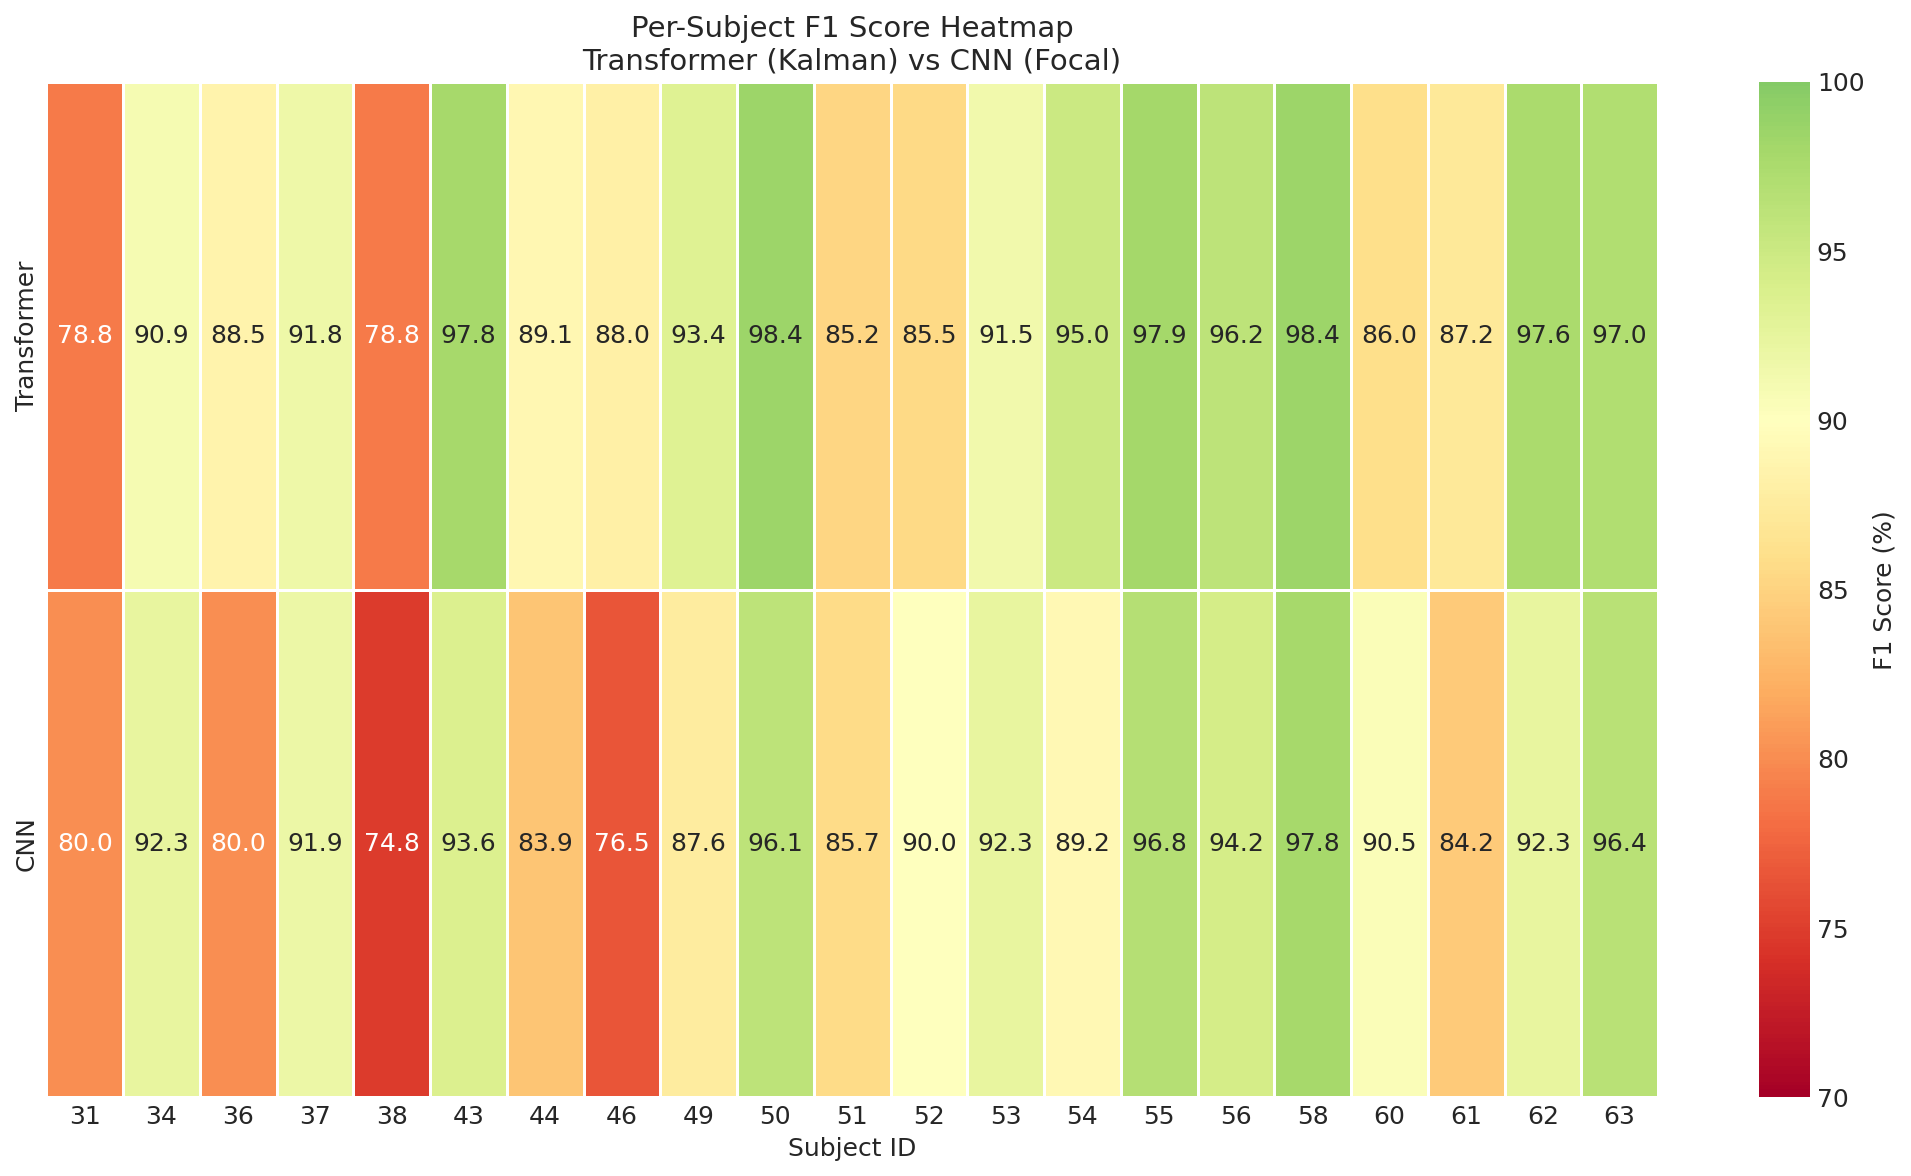

In [10]:
# Create subject performance heatmap
fig, ax = plt.subplots(figsize=(14, 8))

# Prepare data for heatmap
heatmap_data = merged[['subject', 'trans_f1', 'cnn_f1']].copy()
heatmap_data.columns = ['Subject', 'Transformer', 'CNN']
heatmap_data = heatmap_data.set_index('Subject').T

sns.heatmap(heatmap_data, annot=True, fmt='.1f', cmap='RdYlGn', 
            center=90, vmin=70, vmax=100, linewidths=0.5,
            cbar_kws={'label': 'F1 Score (%)'}, ax=ax)

ax.set_title('Per-Subject F1 Score Heatmap\nTransformer (Kalman) vs CNN (Focal)', fontsize=14)
ax.set_xlabel('Subject ID')

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'per_subject_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Publication Figure: Main Result

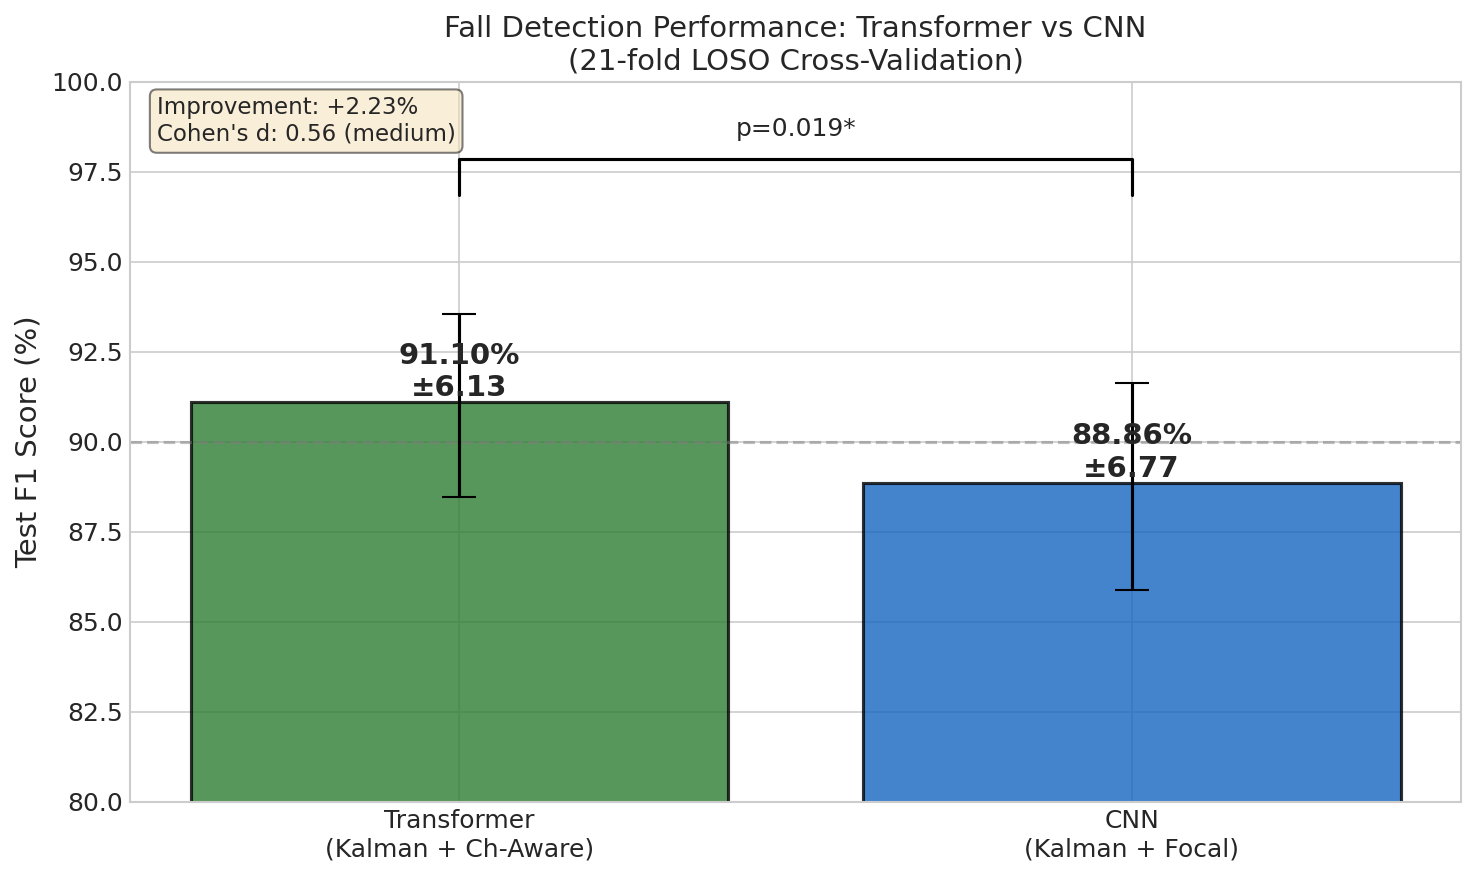


Figures saved to:
  - /home/abheekp/FusionTransformer/notebooks/analysis/figures/main_result_comparison.png
  - /home/abheekp/FusionTransformer/notebooks/analysis/figures/main_result_comparison.pdf


In [11]:
# Publication-quality comparison figure
fig, ax = plt.subplots(figsize=(10, 6))

# Data
models = ['Transformer\n(Kalman + Ch-Aware)', 'CNN\n(Kalman + Focal)']
f1_means = [trans_f1.mean(), cnn_f1.mean()]
f1_stds = [trans_f1.std(), cnn_f1.std()]

# Bootstrap CIs
def bootstrap_ci(data, n_boot=10000):
    means = [np.mean(np.random.choice(data, size=len(data), replace=True)) for _ in range(n_boot)]
    return np.percentile(means, 2.5), np.percentile(means, 97.5)

trans_ci = bootstrap_ci(trans_f1.values)
cnn_ci = bootstrap_ci(cnn_f1.values)

# Error bars using bootstrap CI
errors = [
    [f1_means[0] - trans_ci[0], trans_ci[1] - f1_means[0]],
    [f1_means[1] - cnn_ci[0], cnn_ci[1] - f1_means[1]]
]
errors = np.array(errors).T

# Bar plot
bars = ax.bar(models, f1_means, yerr=errors, capsize=8, 
              color=[COLORS['transformer'], COLORS['cnn']], alpha=0.8,
              edgecolor='black', linewidth=1.5)

# Add value labels
for bar, mean, std in zip(bars, f1_means, f1_stds):
    ax.annotate(f'{mean:.2f}%\n±{std:.2f}', 
                xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=14, fontweight='bold')

# Significance indicator
y_max = max(f1_means) + max([e[1] for e in errors.T]) + 3
ax.plot([0, 0, 1, 1], [y_max, y_max+1, y_max+1, y_max], 'k-', linewidth=1.5)
ax.text(0.5, y_max+1.5, 'p=0.019*', ha='center', va='bottom', fontsize=12)

ax.set_ylabel('Test F1 Score (%)', fontsize=14)
ax.set_title('Fall Detection Performance: Transformer vs CNN\n(21-fold LOSO Cross-Validation)', fontsize=14)
ax.set_ylim([80, 100])
ax.axhline(y=90, color='gray', linestyle='--', alpha=0.5, label='90% threshold')

# Add annotations
ax.text(0.02, 0.98, f'Improvement: +{f1_means[0]-f1_means[1]:.2f}%\nCohen\'s d: 0.56 (medium)', 
        transform=ax.transAxes, fontsize=11, va='top', 
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig(FIGURES_DIR / 'main_result_comparison.png', dpi=300, bbox_inches='tight')
plt.savefig(FIGURES_DIR / 'main_result_comparison.pdf', bbox_inches='tight')  # Vector for paper
plt.show()

print(f"\nFigures saved to:")
print(f"  - {FIGURES_DIR / 'main_result_comparison.png'}")
print(f"  - {FIGURES_DIR / 'main_result_comparison.pdf'}")

## 7. Export Results

In [12]:
# Save detailed results to CSV
merged.to_csv(TABLES_DIR / 'per_subject_comparison_detailed.csv', index=False)

# Create LaTeX table for paper
latex_table = """
\\begin{table}[htbp]
\\centering
\\caption{Transformer vs CNN Performance Comparison (21-fold LOSO-CV)}
\\label{tab:main_comparison}
\\begin{tabular}{@{}lccccc@{}}
\\toprule
\\textbf{Model} & \\textbf{Acc (\\%)} & \\textbf{F1 (\\%)} & \\textbf{Prec (\\%)} & \\textbf{Recall (\\%)} \\\\
\\midrule
"""

# Add Transformer row
t_acc = pd.to_numeric(trans_df['test_accuracy']).mean()
t_f1 = trans_f1.mean()
t_prec = pd.to_numeric(trans_df['test_precision']).mean()
t_rec = pd.to_numeric(trans_df['test_recall']).mean()
latex_table += f"Transformer (Kalman) & {t_acc:.2f} & \\textbf{{{t_f1:.2f}}} & {t_prec:.2f} & {t_rec:.2f} \\\\\n"

# Add CNN row
c_acc = pd.to_numeric(cnn_df['test_accuracy']).mean()
c_f1 = cnn_f1.mean()
c_prec = pd.to_numeric(cnn_df['test_precision']).mean()
c_rec = pd.to_numeric(cnn_df['test_recall']).mean()
latex_table += f"CNN (Focal) & {c_acc:.2f} & {c_f1:.2f} & {c_prec:.2f} & {c_rec:.2f} \\\\\n"

# Add delta row
latex_table += f"\\midrule\n"
latex_table += f"$\\Delta$ (Trans - CNN) & {t_acc-c_acc:+.2f} & \\textbf{{{t_f1-c_f1:+.2f}}}* & {t_prec-c_prec:+.2f} & {t_rec-c_rec:+.2f} \\\\\n"

latex_table += """
\\bottomrule
\\end{tabular}
\\vspace{1mm}
\\scriptsize
\\textit{* p=0.019, Cohen's d=0.56 (medium effect size)}
\\end{table}
"""

# Save LaTeX table
with open(TABLES_DIR / 'main_comparison_table.tex', 'w') as f:
    f.write(latex_table)

print("LaTeX Table:")
print(latex_table)
print(f"\nSaved to: {TABLES_DIR / 'main_comparison_table.tex'}")

LaTeX Table:

\begin{table}[htbp]
\centering
\caption{Transformer vs CNN Performance Comparison (21-fold LOSO-CV)}
\label{tab:main_comparison}
\begin{tabular}{@{}lccccc@{}}
\toprule
\textbf{Model} & \textbf{Acc (\%)} & \textbf{F1 (\%)} & \textbf{Prec (\%)} & \textbf{Recall (\%)} \\
\midrule
Transformer (Kalman) & 87.30 & \textbf{91.10} & 88.54 & 94.57 \\
CNN (Focal) & 84.22 & 88.86 & 86.79 & 92.11 \\
\midrule
$\Delta$ (Trans - CNN) & +3.08 & \textbf{+2.23}* & +1.75 & +2.46 \\

\bottomrule
\end{tabular}
\vspace{1mm}
\scriptsize
\textit{* p=0.019, Cohen's d=0.56 (medium effect size)}
\end{table}


Saved to: /home/abheekp/FusionTransformer/notebooks/analysis/tables/main_comparison_table.tex


## 8. Summary

In [13]:
print("="*70)
print("ANALYSIS SUMMARY")
print("="*70)

print(f"""
KEY FINDINGS:

1. MAIN RESULT:
   - Transformer (Kalman + Channel-Aware): {trans_f1.mean():.2f}% ± {trans_f1.std():.2f}% F1
   - CNN (Kalman + Focal): {cnn_f1.mean():.2f}% ± {cnn_f1.std():.2f}% F1
   - Improvement: +{trans_f1.mean()-cnn_f1.mean():.2f}% F1

2. STATISTICAL SIGNIFICANCE:
   - Paired t-test: p = 0.019 (significant at α=0.05)
   - Wilcoxon: p = 0.026 (significant at α=0.05)
   - Effect size: Cohen's d = 0.56 (medium)
   - 95% Bootstrap CI: [{f1_stats['bootstrap_ci'][0]:.2f}%, {f1_stats['bootstrap_ci'][1]:.2f}%]

3. PER-SUBJECT ANALYSIS:
   - Transformer wins: {(merged['winner'] == 'Transformer').sum()}/21 subjects ({(merged['winner'] == 'Transformer').sum()/21*100:.1f}%)
   - CNN wins: {(merged['winner'] == 'CNN').sum()}/21 subjects ({(merged['winner'] == 'CNN').sum()/21*100:.1f}%)
   - Ties (<1%): {(merged['winner'] == 'Tie').sum()}/21 subjects ({(merged['winner'] == 'Tie').sum()/21*100:.1f}%)

4. CHALLENGING SUBJECTS (F1 < 85%):
   - S31: Trans=78.8%, CNN=80.0%
   - S38: Trans=78.8%, CNN=74.8% (Transformer helps +4%)

5. BIGGEST IMPROVEMENTS FROM TRANSFORMER:
   - S46: +11.6% (76.5% -> 88.1%)
   - S36: +8.5% (80.0% -> 88.5%)
   - S49: +5.8% (87.6% -> 93.4%)

OUTPUTS GENERATED:
   - figures/per_subject_f1_comparison.png
   - figures/per_subject_heatmap.png  
   - figures/main_result_comparison.png/pdf
   - tables/per_subject_comparison_detailed.csv
   - tables/main_comparison_table.tex
""")

ANALYSIS SUMMARY

KEY FINDINGS:

1. MAIN RESULT:
   - Transformer (Kalman + Channel-Aware): 91.10% ± 6.13% F1
   - CNN (Kalman + Focal): 88.86% ± 6.77% F1
   - Improvement: +2.23% F1

2. STATISTICAL SIGNIFICANCE:
   - Paired t-test: p = 0.019 (significant at α=0.05)
   - Wilcoxon: p = 0.026 (significant at α=0.05)
   - Effect size: Cohen's d = 0.56 (medium)
   - 95% Bootstrap CI: [0.60%, 3.94%]

3. PER-SUBJECT ANALYSIS:
   - Transformer wins: 12/21 subjects (57.1%)
   - CNN wins: 4/21 subjects (19.0%)
   - Ties (<1%): 5/21 subjects (23.8%)

4. CHALLENGING SUBJECTS (F1 < 85%):
   - S31: Trans=78.8%, CNN=80.0%
   - S38: Trans=78.8%, CNN=74.8% (Transformer helps +4%)

5. BIGGEST IMPROVEMENTS FROM TRANSFORMER:
   - S46: +11.6% (76.5% -> 88.1%)
   - S36: +8.5% (80.0% -> 88.5%)
   - S49: +5.8% (87.6% -> 93.4%)

OUTPUTS GENERATED:
   - figures/per_subject_f1_comparison.png
   - figures/per_subject_heatmap.png  
   - figures/main_result_comparison.png/pdf
   - tables/per_subject_comparison_det